Data taken from :
https://www.kaggle.com/datasets/laotse/credit-risk-dataset?resource=download


Data Description:
Feature Name	                 -- Description
1. person_age	                 -- Age
2. person_income	             -- Annual Income
3. person_home_ownership	     -- Home ownership
4. person_emp_length	         -- Employment length (in years)
5. loan_intent	               -- Loan intent
6. loan_grade	                 -- Loan grade
7. loan_amnt	                 -- Loan amount
8. loan_int_rate	             -- Interest rate
9. loan_status	               -- Loan status (0 is non default 1 is default)
10. loan_percent_income	       -- Percent income
11. cb_person_default_on_file  -- Historical default
12. cb_preson_cred_hist_length -- Credit history length

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
df=pd.read_csv('/content/drive/MyDrive/PRO/Analytics - Projects/Credit Risk Analytics/credit_risk_dataset.csv')

In [5]:
import sqlite3

In [6]:
# Connect to SQLite database (creates a new database if it doesn't exist)
conn = sqlite3.connect('CRA.sqlite')

# Use the DataFrame's to_sql() method to create a table and insert data
df.to_sql(name='crds', con=conn, index=False, if_exists='replace')

# Commit the changes
conn.commit()

In [7]:
query = 'select * from crds'
df1 = pd.read_sql(query, conn)
df1

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [8]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


Who is most likely to default?

Business Question:
Which **customer segments** have the highest probability of loan default?

Columns that can be used:
1. person_age,
2. person_income,
3. loan_grade,
4. loan_int_rate,
5. cb_person_default_on_file,
6. loan_status

In [9]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

Does age affect default risk?

Question:
Are younger borrowers more likely to default compared to older customers?

In [10]:
query = 'select person_age, count(loan_status) as Count from crds where loan_status is 1 group by person_age order by 2 desc'
df1 = pd.read_sql(query, conn)
df1.head()

,person_age,Count
0,22,884
1,23,833
2,24,769
3,25,675
4,26,517


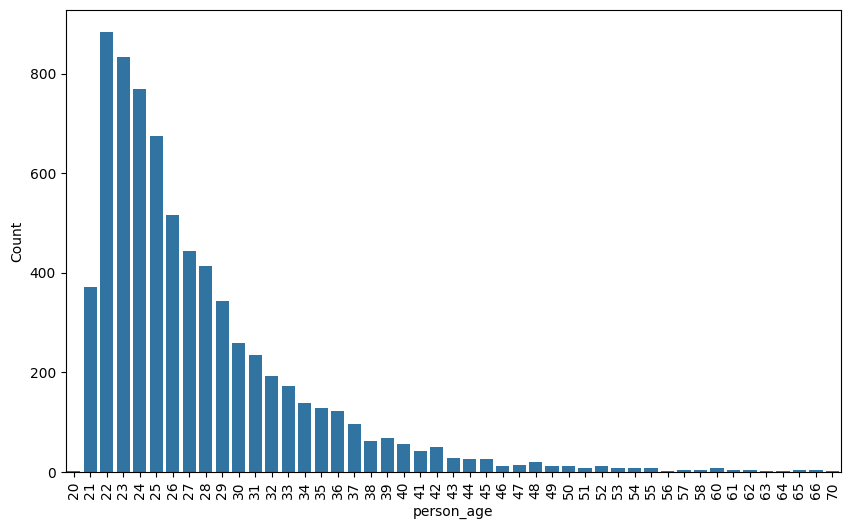

In [11]:
plt.figure(figsize=(10,6))
sns.barplot(x='person_age', y='Count', data =df1)
plt.xticks(rotation=90)
plt.show()

Age seem to have a strong correlation with Default Rates with younger audience defaulting more.

And Underwriting rules can be designed by taking this into account (age-based underwriting rules).

How does income impact loan default?

Question:
Is there a threshold income below which default rates sharply increase?

In [12]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [13]:
query = 'select max(person_income), min(person_income) from crds'
df2 = pd.read_sql(query, conn)
df2

,max(person_income),min(person_income)
0,6000000,4000


In [14]:
query = 'select person_income from crds'
df2 = pd.read_sql(query, conn)
df2.head()

,person_income
0,59000
1,9600
2,9600
3,65500
4,54400


In [15]:
query = """
select
case when person_income<10000 then 'Under_10k'
  when person_income<20000 then 'Under_20k'
  when person_income<30000 then 'Under_30k'
  when person_income<50000 then 'Under_50k'
  when person_income<100000 then 'Under_100k'
  when person_income<200000 then 'Under_200k'
  else 'Above_200k'
end as Income_Category, count(loan_status) as Count
from crds
where loan_status=1
group by 1
order by 2 desc
"""
df3 = pd.read_sql(query, conn)
df3

,Income_Category,Count
0,Under_50k,2712
1,Under_100k,2261
2,Under_30k,881
3,Under_20k,785
4,Under_200k,354
5,Under_10k,61
6,Above_200k,54


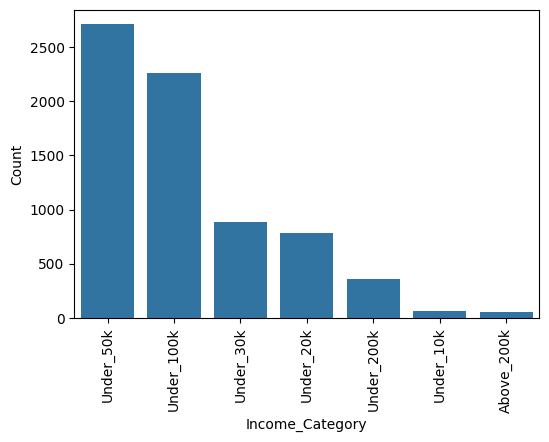

In [16]:
plt.figure(figsize=(6,4))
sns.barplot(x='Income_Category', y='Count', data =df3)
plt.xticks(rotation=90)
plt.show()

Between 30k to 50k lies most of the Defaulters which is neither too low income nor too high.
And then comes the Category >50k and <100k.

Therefore most Defaulters lies in bracket >30k and <100k. That Category could have strong Underwriting Experience.

Also there are some cases of >200k whom are defaulting.
Its important to understand the amount for which they are defaulting as they are high income category so loan amount could also be high which makes it much more risky even though frequency is few.

Also It is important to understand the count of total peoples in each of these categories so to understand the percentage of them defaulting and if there are ones(categories) which are most of the time defaulting.



In [17]:
query = """
select person_income, loan_amnt
from crds
where person_income>200000 and loan_status=1
order by 2 desc
"""
df4 = pd.read_sql(query, conn)
df4.head(15)

,person_income,loan_amnt
0,213000,35000
1,325550,35000
2,258000,35000
3,228000,35000
4,213000,35000
5,219300,35000
6,258000,35000
7,540600,35000
8,403750,35000
9,244800,35000


Notably the max amount of loan is 35000 for income category >200k which has been taken by 9 persons.

Let's check overall income vs loan amount to get an idea whether loan amount is severely correlated with income or not.

In [18]:
query = """
select person_income, loan_amnt
from crds
order by 2 desc
"""
df5 = pd.read_sql(query, conn)

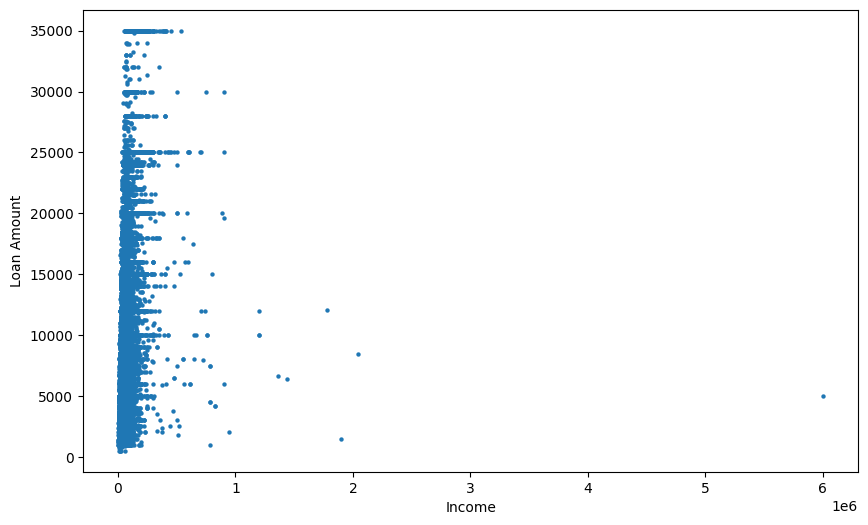

In [19]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='person_income', y='loan_amnt', data =df5, s=10, linewidth=0)
plt.xlabel('Income')
plt.ylabel('Loan Amount')
plt.show()

It doesn't really show a strong correlation between Income and Loan Amount. Therefore High Income people need not have a strong Underwriting Experience.

Understanding Total Candidates in each category who have taken loan.

In [20]:
query = """
select
case when person_income<10000 then 'Under_10k'
  when person_income<20000 then 'Under_20k'
  when person_income<30000 then 'Under_30k'
  when person_income<50000 then 'Under_50k'
  when person_income<100000 then 'Under_100k'
  when person_income<200000 then 'Under_200k'
  else 'Above_200k'
end as Income_Category, count(loan_status) as Count
from crds
group by 1
order by 2 desc
"""
df6 = pd.read_sql(query, conn)
df6

,Income_Category,Count
0,Under_100k,14707
1,Under_50k,9635
2,Under_200k,4031
3,Under_30k,2625
4,Under_20k,970
5,Above_200k,539
6,Under_10k,74


In [21]:
df3

,Income_Category,Count
0,Under_50k,2712
1,Under_100k,2261
2,Under_30k,881
3,Under_20k,785
4,Under_200k,354
5,Under_10k,61
6,Above_200k,54


In [22]:
df_income = df3.merge(df6, on='Income_Category')

In [23]:
df_income

,Income_Category,Count_x,Count_y
0,Under_50k,2712,9635
1,Under_100k,2261,14707
2,Under_30k,881,2625
3,Under_20k,785,970
4,Under_200k,354,4031
5,Under_10k,61,74
6,Above_200k,54,539


In [24]:
df_income.columns = ['Income_Category','Count_Defaulters', 'Total_Count']

In [25]:
df_income

,Income_Category,Count_Defaulters,Total_Count
0,Under_50k,2712,9635
1,Under_100k,2261,14707
2,Under_30k,881,2625
3,Under_20k,785,970
4,Under_200k,354,4031
5,Under_10k,61,74
6,Above_200k,54,539


In [26]:
df_income['% Defaulted'] = df_income['Count_Defaulters']/df_income['Total_Count']*100

In [27]:
df_income

,Income_Category,Count_Defaulters,Total_Count,% Defaulted
0,Under_50k,2712,9635,28.147379
1,Under_100k,2261,14707,15.373632
2,Under_30k,881,2625,33.561905
3,Under_20k,785,970,80.927835
4,Under_200k,354,4031,8.781940
5,Under_10k,61,74,82.432432
6,Above_200k,54,539,10.018553


This completely changes the story.

"It now makes sense to have much stronger Underwriting for under 10k and under 20k categories as they are almost 80% of times defaulting."

Also we have kind of seen the Loan Amount is kind of not correlated with Income, so even small income candidates might have been taking larger loans. Therefore above statement makes sense.

Also as income grows, % of defaulters are almost decreasing strongly.





**Next**

Does home ownership reduce credit risk?

Question:
Do homeowners default less than renters?

In [28]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [29]:
query = """
select person_home_ownership,
sum(case when loan_status=1 then 1 else 0 end)*100.0/count(loan_status) as perc_Defaulter,
count(loan_status) as Total_Count,
sum(case when loan_status=1 then 1 else 0 end) as Count_Defaulter
from crds
group by 1
order by 2 desc
"""
df7 = pd.read_sql(query, conn)
df7

,person_home_ownership,perc_Defaulter,Total_Count,Count_Defaulter
0,RENT,31.569987,16446,5192
1,OTHER,30.841121,107,33
2,MORTGAGE,12.570663,13444,1690
3,OWN,7.469040,2584,193


Above Analysis can be useful in Risk Scoring Models.

Percent of people defaulting is highest in RENT category including the count of them as well is the highest.
Therefore a stronger Underwriting must need to be present for the ones with Home Ownership as RENT.

Secondly Countwise the second highest ones are the ones with MORTGAGE, however the percent of them is much lower than the RENT category, so there can be leniency present to them compared to RENT category.

**NEXT**:

Are people with longer employment histories less likely to default?

*Business value*:
Helps set minimum employment requirements.

In [30]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [31]:
query = 'select person_emp_length from crds order by 1 desc'
df8 = pd.read_sql(query, conn)
df8

,person_emp_length
0,123.0
1,123.0
2,41.0
3,38.0
4,34.0
...,...
32576,NaN
32577,NaN
32578,NaN
32579,NaN


In [32]:
query = """
select
case when person_emp_length<=2 then 'Under or equal to 2'
  when person_emp_length<5 then 'Under_5'
  when person_emp_length<10 then 'Under_10'
  when person_emp_length<15 then 'Under_15'
  when person_emp_length<20 then 'Under_20'
  when person_emp_length<30 then 'Under_30'
  when person_emp_length<40 then 'Under_40'
  when person_emp_length<50 then 'Under_50'
  when person_emp_length is NULL then 'NaN'
  else 'Above or equal to 50'
end as Employment_Category,
sum(case when loan_status=1 then 1 else 0 end)*100.0/count(loan_status) as perc_Defaulter,
count(loan_status) as Total_Count,
sum(case when loan_status=1 then 1 else 0 end) as Count_Defaulter
from crds
group by 1
order by 2 desc
"""
df9 = pd.read_sql(query, conn)
df9

,Employment_Category,perc_Defaulter,Total_Count,Count_Defaulter
0,Above or equal to 50,50.000000,2,1
1,NaN,31.508380,895,282
2,Under or equal to 2,27.049407,10869,2940
3,Under_40,25.000000,8,2
4,Under_30,24.647887,142,35
5,Under_5,20.631912,6330,1306
6,Under_10,18.274719,10862,1985
7,Under_15,16.305916,2772,452
8,Under_20,15.000000,700,105
9,Under_50,0.000000,1,0


No clear pattern , however the ones with under 2 years of employment and unknown history constitutes the highest percentage in terms of defaulting.
Also the number of defaulters are highest for Under 2 category.

So atleast 2 years of employment could drastically reduce the chance of defaulting as it will mitigate both NAN catgeory and Under 2 year category.

Next:

**Loan Characteristics Analysis**

In [33]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

Which loan intents have the highest default rate?

Question:
1. Do loans taken for education, personal use, or medical reasons default more often?

Some loan purposes may need stricter approval criteria.

In [34]:
df['loan_intent'].value_counts()

,count
loan_intent,
EDUCATION,6453
MEDICAL,6071
VENTURE,5719
PERSONAL,5521
DEBTCONSOLIDATION,5212
HOMEIMPROVEMENT,3605


In [35]:
query = """
select
loan_intent,
sum(case when loan_status=1 then 1 else 0 end)*100.0/count(loan_status) as perc_Defaulter,
count(loan_status) as Total_Count,
sum(case when loan_status=1 then 1 else 0 end) as Count_Defaulter
from crds
group by 1
order by 2 desc
"""
df10 = pd.read_sql(query, conn)
df10

,loan_intent,perc_Defaulter,Total_Count,Count_Defaulter
0,DEBTCONSOLIDATION,28.587874,5212,1490
1,MEDICAL,26.700708,6071,1621
2,HOMEIMPROVEMENT,26.102635,3605,941
3,PERSONAL,19.887702,5521,1098
4,EDUCATION,17.216798,6453,1111
5,VENTURE,14.810282,5719,847


1. Personal, Education, Venture have low percent Defaulters.

2. Homeimprovement have low loan taken count but high percent of Defaulters. So this could be the area where the Sales pitch step could take a backstep and focus of Sales could be focussed on areas of Venture, Education and Personal in order.

3. DebtConsolidation, and Medical both have high percent defaulters but their loan taken count is also high. Especially Medical have much higher loan_taken count but percent default is slightly lower than DebtConsolidation. So these could be the areas where focus should be on stricter loan approval mechanism and Sales pitch could be as it is or improved.

4. Also Medical could be the area where focus can be shifted overall as it could help garner much revenue and with strict approval mechanism if default rate is decreased then Growth could be exponential.

Validating whether credit grading system is effective

In [36]:
query = """
select
loan_grade,
sum(case when loan_status=1 then 1 else 0 end)*100.0/count(loan_status) as perc_Defaulter,
sum(loan_amnt) as Total_Loan_Amount,
count(loan_status) as Total_Count,
sum(case when loan_status=1 then 1 else 0 end) as Count_Defaulter
from crds
group by 1
order by 2 desc, 3 desc
"""
df11 = pd.read_sql(query, conn)
df11

,loan_grade,perc_Defaulter,Total_Loan_Amount,Total_Count,Count_Defaulter
0,G,98.437500,1100525,64,63
1,F,70.539419,3546875,241,170
2,E,64.419087,12450875,964,621
3,D,59.045780,39339350,3626,2141
4,C,20.733973,59503125,6458,1339
5,B,16.275954,104462800,10451,1701
6,A,9.956389,92027750,10777,1073


Loan Grade B has more default rate than A which is expected but is also contributing to more Loan Amount given which is where the focus should be and so the focus should be on producing more loan (especially loan amount) which is grade A.

In terms of Loan Count A has more loans but Total amount of B is exceeding A which means there are some high end loans given in Category B, and so the focus should be is on converting those loans to grade A.

Or simply put, customers should be found with grade A attributes which are requiring high end loans since A grade contributes to small default rates.

Are larger loans riskier?

Question:
Does the probability of default increase as loan amount increases?

<Axes: xlabel='loan_status', ylabel='loan_amnt'>

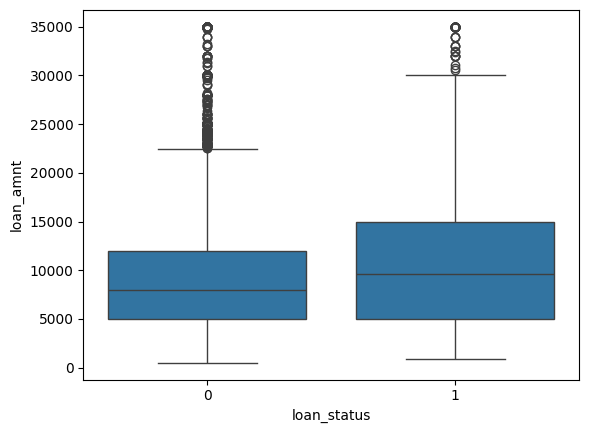

In [37]:
sns.boxplot(x ='loan_status', y='loan_amnt', data =df)

Clearly the Median and the 75th percentile and whiskers, all three are higher in case of Defaulted loans which tells, people with high end loans seems to tend to default more.

Also notably there are people in both defaulters and non defaulters category who have taken extreme loans reaching upto 35k $ or more.

In [38]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

<Axes: ylabel='loan_int_rate'>

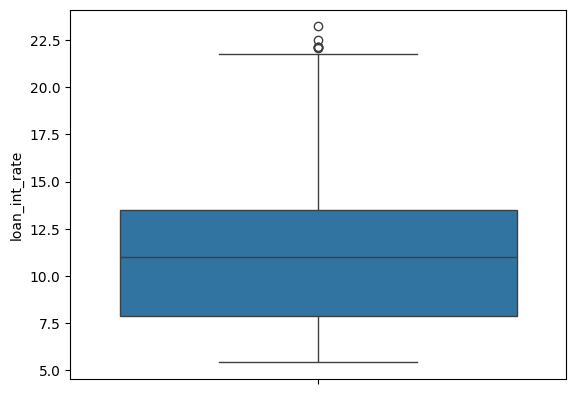

In [39]:
sns.boxplot(y = 'loan_int_rate', data = df)

In [40]:
df['loan_int_rate'].isnull().sum()

np.int64(3116)

In [41]:
query = """
select
case when loan_int_rate<=5 then 'Under or equal to 5'
  when loan_int_rate<7 then 'Under_5'
  when loan_int_rate<8 then 'Under_8'
  when loan_int_rate<9 then 'Under_9'
  when loan_int_rate<10 then 'Under_10'
  when loan_int_rate<11 then 'Under_11'
  when loan_int_rate<12 then 'Under_12'
  when loan_int_rate<13 then 'Under_13'
  when loan_int_rate<14 then 'Under_14'
  when loan_int_rate<15 then 'Under_15'
  when loan_int_rate<16 then 'Under_16'
  when loan_int_rate<17 then 'Under_17'
  when loan_int_rate<20 then 'Under_20'
  when loan_int_rate is NULL then 'NaN'
  else 'Above or equal to 20'
end as Loan_int_Category,
sum(case when loan_status=1 then 1 else 0 end)*100.0/count(loan_status) as perc_Defaulter,
count(loan_status) as Total_Count,
sum(case when loan_status=1 then 1 else 0 end) as Count_Defaulter
from crds
group by 1
order by 2 desc
"""
df12 = pd.read_sql(query, conn)
df12

,Loan_int_Category,perc_Defaulter,Total_Count,Count_Defaulter
0,Above or equal to 20,85.135135,74,63
1,Under_20,66.059818,769,508
2,Under_17,59.593023,1032,615
3,Under_16,51.724138,1566,810
4,Under_15,42.474130,2126,903
5,Under_14,22.260991,2866,638
6,NaN,20.667522,3116,644
7,Under_13,20.081061,2714,545
8,Under_12,16.862861,3398,573
9,Under_11,16.550117,3432,568


Clearly Loan Default is increasing as interest rate is increasing.

The number of people who have taken the loan is invariably distributed across different loan interest rate categories with most loans lying between interest rate 10 and 15.

**NEXT:**

Debt Burden Analysis

10. What is the relationship between income utilization and default?

Question:
Do borrowers spending more than a certain percentage of their income on loan payments default more?

In [43]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

<Axes: xlabel='loan_status', ylabel='loan_percent_income'>

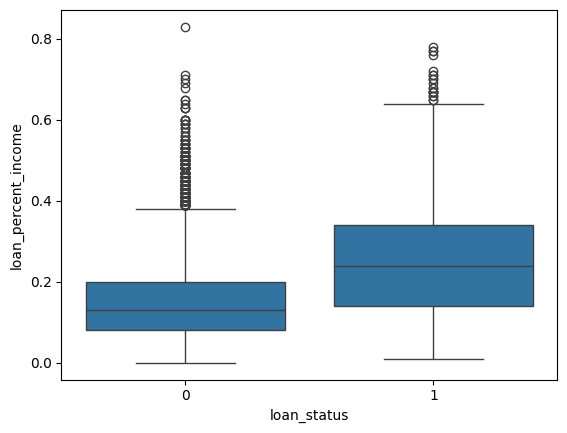

In [44]:
sns.boxplot(x='loan_status', y='loan_percent_income', data = df)

<Axes: xlabel='loan_percent_income', ylabel='person_income'>

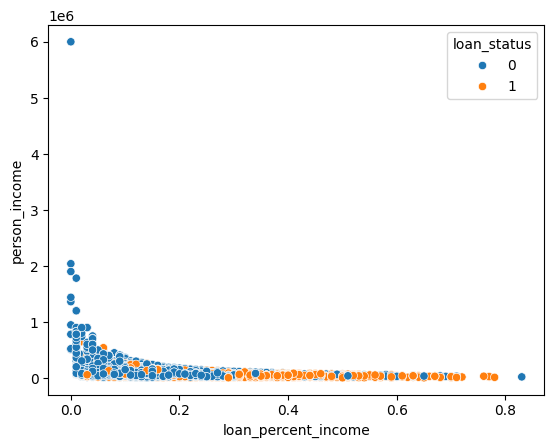

In [46]:
sns.scatterplot(x='loan_percent_income', y='person_income', data =df, hue ='loan_status')

Above graph tells when loan_percent_income increased, Defaulters also increased.

Let's check that in more detail.

In [47]:
df['loan_percent_income'].isnull().sum()

np.int64(0)

In [50]:
query = """
select
case when loan_percent_income<0.1 then 'Under_0.1'
  when loan_percent_income<0.2 then 'Under_0.2'
  when loan_percent_income<0.3 then 'Under_0.3'
  when loan_percent_income<0.4 then 'Under_0.4'
  when loan_percent_income<0.5 then 'Under_0.5'
  when loan_percent_income<0.6 then 'Under_0.6'
  when loan_percent_income<0.7 then 'Under_0.7'
  when loan_percent_income<0.8 then 'Under_0.8'
  when loan_percent_income<0.9 then 'Under_0.9'
  when loan_percent_income<=1 then 'Under_or_equal_to_1'
  else 'Above_1'
end as Loan_percent_income_Category,
sum(case when loan_status=1 then 1 else 0 end)*100.0/count(loan_status) as perc_Defaulter,
count(loan_status) as Total_Count,
sum(case when loan_status=1 then 1 else 0 end) as Count_Defaulter
from crds
group by 1
order by 2 desc
"""
df13 = pd.read_sql(query, conn)
df13

,Loan_percent_income_Category,perc_Defaulter,Total_Count,Count_Defaulter
0,Under_0.8,81.818182,11,9
1,Under_0.6,77.454545,275,213
2,Under_0.7,73.469388,49,36
3,Under_0.5,72.572573,999,725
4,Under_0.4,61.762712,2950,1822
5,Under_0.3,20.888954,6817,1424
6,Under_0.2,14.734994,12528,1846
7,Under_0.1,11.540610,8951,1033
8,Under_0.9,0.000000,1,0


As Loan_percent_income increased, percent Defaulter also increased, which tells the people with more constraints on paying back loan tend to default more.

But notably total number of people in those brackets are also invariably low which tells about bank not providing loans to those people in larger number or might have taken this constraint in account already.

Safest bracket is Under 0.1 category. Also though Under_0.9 category has 0 percent default rate but that only has 1 candidate, so data is insufficient for that bracket.

**NEXT:**

Does credit history length reduce default risk?

Question:
Are customers with longer credit histories more reliable?

In [51]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

<Axes: xlabel='loan_status', ylabel='cb_person_cred_hist_length'>

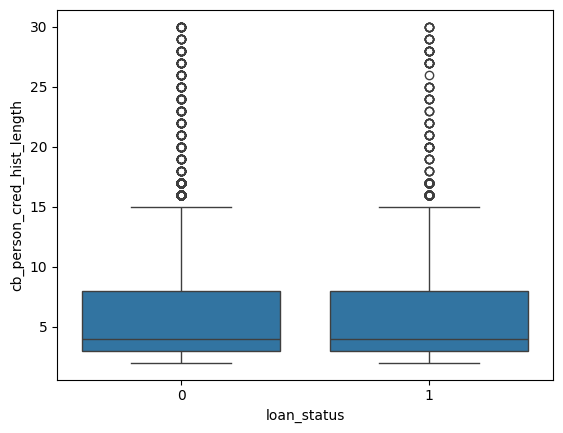

In [66]:
sns.boxplot(x='loan_status', y='cb_person_cred_hist_length', data = df)

In [58]:
df['cb_person_cred_hist_length'].max()

30

In [60]:
df['cb_person_cred_hist_length'].min()

2

In [67]:
query = """
select
case when cb_person_cred_hist_length<2 then 'Under_2'
  when cb_person_cred_hist_length<3 then 'Between_2_and_3'
  when cb_person_cred_hist_length<4 then 'Between_3_and_4'
  when cb_person_cred_hist_length<5 then 'Between_4_and_5'
  when cb_person_cred_hist_length<6 then 'Between_5_and_6'
  when cb_person_cred_hist_length<7 then 'Between_6_and_7'
  when cb_person_cred_hist_length<10 then 'Between_7_and_10'
  when cb_person_cred_hist_length<15 then 'Between_10_and_15'
  when cb_person_cred_hist_length<20 then 'Between_15_and_20'
  when cb_person_cred_hist_length<25 then 'Between_20_and_25'
  when cb_person_cred_hist_length<31 then 'Between_25_and_31'
  else 'Above_30'
end as Credit_history_length,
sum(case when loan_status=1 then 1 else 0 end)*100.0/count(loan_status) as perc_Defaulter,
count(loan_status) as Total_Count,
sum(case when loan_status=1 then 1 else 0 end) as Count_Defaulter
from crds
group by 1
order by 2 desc
"""
df14 = pd.read_sql(query, conn)
df14

,Credit_history_length,perc_Defaulter,Total_Count,Count_Defaulter
0,Between_25_and_31,28.571429,119,34
1,Between_20_and_25,24.000000,125,30
2,Between_2_and_3,23.570830,5965,1406
3,Between_4_and_5,22.312236,5925,1322
4,Between_3_and_4,22.278311,5943,1324
5,Between_15_and_20,20.898876,1335,279
6,Between_6_and_7,20.786214,1857,386
7,Between_7_and_10,20.709021,5698,1180
8,Between_5_and_6,20.627326,1881,388
9,Between_10_and_15,20.332173,3733,759


There is no clear pattern in defaulters varied from non defaulters based on Credit history length.

Also the people with most credit history length have highest default rate which is very different from natural behavioral characteristic of users "where more credit history should make them reliable".

So let's study these users a bit:

In [73]:
query = """
select cb_person_cred_hist_length,
sum(case when loan_status=1 then 1 else 0 end)*100.0/count(loan_status) as perc_Defaulter,
sum(loan_amnt) as Total_Loan_Amount,
count(loan_status) as Total_Count,
sum(case when loan_status=1 then 1 else 0 end) as Count_Defaulter
from crds
where cb_person_cred_hist_length > 24.99 and cb_person_cred_hist_length< 31
group by 1
order by 2 desc
"""
df15 = pd.read_sql(query, conn)
df15

,cb_person_cred_hist_length,perc_Defaulter,Total_Loan_Amount,Total_Count,Count_Defaulter
0,29,42.857143,119250,14,6
1,27,36.363636,249050,22,8
2,28,33.333333,295175,27,9
3,25,27.777778,186300,18,5
4,30,22.727273,231625,22,5
5,26,6.250000,140300,16,1


In [75]:
query = """
select cb_person_cred_hist_length,
loan_status,
loan_amnt
from crds
where cb_person_cred_hist_length > 24.99 and cb_person_cred_hist_length< 31
"""
df16 = pd.read_sql(query, conn)
df16

,cb_person_cred_hist_length,loan_status,loan_amnt
0,25,0,5000
1,28,0,19600
2,27,1,35000
3,29,0,5000
4,27,0,30000
...,...,...,...
114,26,1,20000
115,30,0,5800
116,28,1,35000
117,26,0,15000


<Axes: xlabel='cb_person_cred_hist_length', ylabel='loan_amnt'>

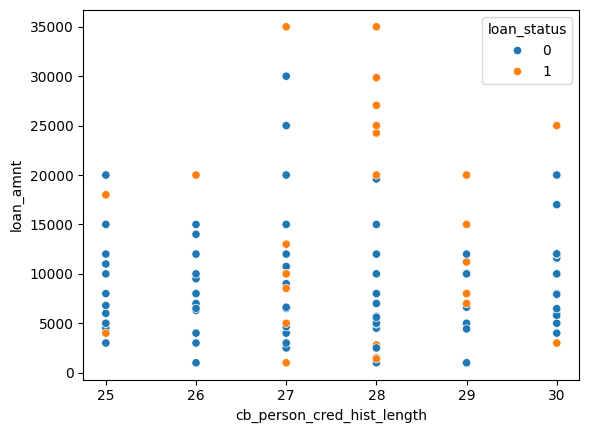

In [76]:
sns.scatterplot(x='cb_person_cred_hist_length', y='loan_amnt', data = df16, hue='loan_status')

No clear pattern among these users, though Above 28 - credit history length combined with high income - 20k or more seems to Default usually.

**NEXT:**

Policy Optimization

18. Should the bank reject customers with prior defaults?

Question:
Is the default rate too high for customers who have defaulted previously?

In [32]:
df['cb_person_default_on_file'].value_counts()

,count
cb_person_default_on_file,
N,26836
Y,5745


In [37]:
len(df[(df['cb_person_default_on_file']=='Y') & (df['loan_status']==1)])/len(df[df['cb_person_default_on_file']=='Y'])

0.37806788511749345

In [38]:
len(df[(df['cb_person_default_on_file']=='N') & (df['loan_status']==1)])/len(df[df['cb_person_default_on_file']=='N'])

0.18393203159934415

37.8 % of all defaulters have defaulted again compared to 18.3 % of Non Defaulters defaulting. This seems like a big jump and provides an area to strictly look at so to frame policy whether to provide loans to such people or not altogether.
I suggest only in rare circumstances these people should be given loan.

Also their defaulting history needs to be carefully analyzed (circumstances they have been in) before putting them in bucket of Defaulters.

**NEXT:**

Pricing and Profitability

16. Is the bank pricing risk correctly?

Question:
Are customers with higher default risk actually being charged higher interest rates?


In [7]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

<Axes: xlabel='loan_status', ylabel='loan_int_rate'>

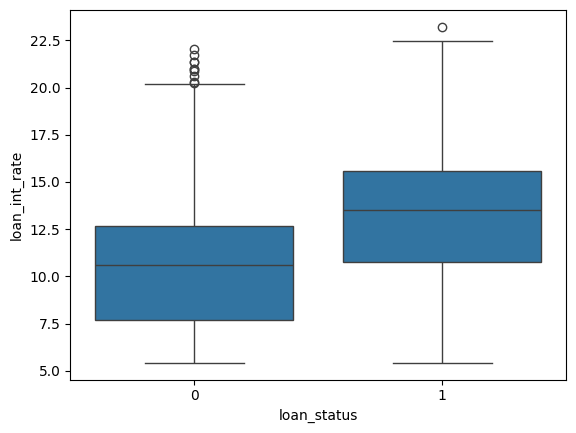

In [8]:
sns.boxplot(x='loan_status', y='loan_int_rate', data=df)

Customers with higher default risk actually being charged higher interest rates in general.

<Axes: xlabel='loan_int_rate', ylabel='loan_amnt'>

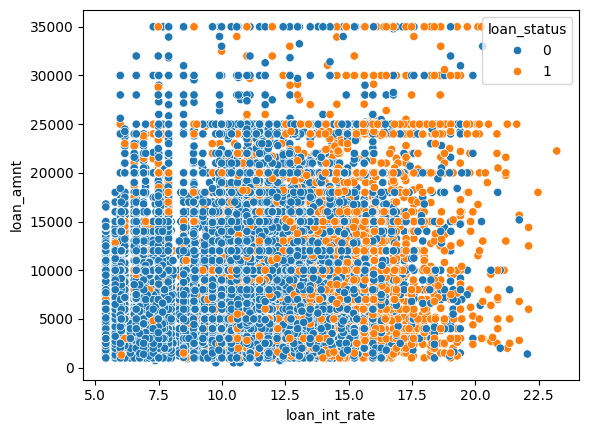

In [11]:
sns.scatterplot(x='loan_int_rate', y='loan_amnt', data =df, hue = 'loan_status')


17. What interest rate range balances risk and profitability?

Question:
At what interest rate does the bank maximize returns without increasing default too much?

In [14]:
df['loan_int_rate'].max()

23.22

In [24]:
query = """
select
case when loan_int_rate<=5 then '0-5'
  when loan_int_rate<7 then '5-7'
  when loan_int_rate<8 then '7-8'
  when loan_int_rate<9 then '8-9'
  when loan_int_rate<10 then '9-10'
  when loan_int_rate<11 then '10-11'
  when loan_int_rate<12 then '11-12'
  when loan_int_rate<13 then '12-13'
  when loan_int_rate<14 then '13-14'
  when loan_int_rate<15 then '14-15'
  when loan_int_rate<16 then '15-16'
  when loan_int_rate<17 then '16-17'
  when loan_int_rate<20 then '17-20'
  when loan_int_rate is NULL then 'NaN'
  else '20-23.2'
end as Loan_int_Category,
sum(loan_amnt) as Total_loan_amnt,
sum(case when loan_status=1 then 1 else 0 end)*100.0/count(loan_status) as perc_Defaulter,
(sum(loan_amnt)*avg(loan_int_rate)/100)- sum(loan_amnt)*(sum(case when loan_status=1 then 1 else 0 end)/count(loan_status)) as Total_Profit
from crds
group by 1
order by 4 desc
"""
df18 = pd.read_sql(query, conn)
df18

,Loan_int_Category,Total_loan_amnt,perc_Defaulter,Total_Profit
0,11-12,33801500,16.862861,3.906420e+06
1,13-14,27470900,22.260991,3.713096e+06
2,10-11,34247625,16.550117,3.630741e+06
3,12-13,26865525,20.081061,3.383930e+06
4,14-15,20844875,42.474130,3.029867e+06
5,7-8,35278675,10.816175,2.676916e+06
6,15-16,16505825,51.724138,2.562623e+06
7,5-7,30916000,7.863065,1.932621e+06
8,17-20,10629075,66.059818,1.923758e+06
9,16-17,11569750,59.593023,1.902219e+06


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, '11-12'),
  Text(1, 0, '13-14'),
  Text(2, 0, '10-11'),
  Text(3, 0, '12-13'),
  Text(4, 0, '14-15'),
  Text(5, 0, '7-8'),
  Text(6, 0, '15-16'),
  Text(7, 0, '5-7'),
  Text(8, 0, '17-20'),
  Text(9, 0, '16-17'),
  Text(10, 0, '9-10'),
  Text(11, 0, '8-9'),
  Text(12, 0, '20-23.2'),
  Text(13, 0, 'NaN')])

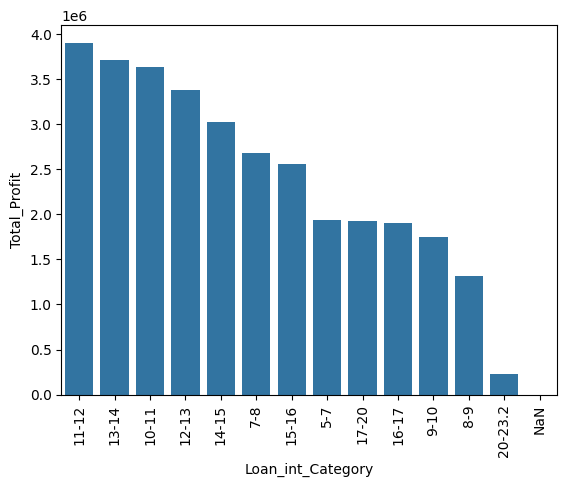

In [22]:
sns.barplot(x='Loan_int_Category', y='Total_Profit', data = df18)
plt.xticks(rotation=90)

Maximum Profit lies 10-15 interest rate and 11-12 being maximum within that.

So this could be the interest rate that bank can target for maximum profit and lowest risk based on trends. And assuming bank has certain criteria for someone to come under this interest rate category. Those are the segment of customers banks should target and put most of their Marketing and Sales efforts on.

**NEXT Analysis in pdf:**

Portfolio Risk Management


14. Which combination of factors produces the highest default risk?

Question:
What combination of income, age, and loan amount creates the highest risk?

Business value:
Identify high-risk customer profiles.


---


15. What are the safest borrower profiles?

Question:
Which customer segments consistently show the lowest default rates?


---


19. What approval rules would minimize default?

Question:
What combination of rules (income, credit history, employment) would reduce default the most?